In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

Calcular area bajo la curva

In [ ]:
x = sp.Symbol('x')

funcion = sp.exp(x)

funcion
# area = 

# Sumas de Riemann

Definir el rango y la función a calcular el área bajo la curva

In [2]:
def getXRange(xmin, xmax, N, mode):
    dx = (xmax - xmin) / N
    x = np.linspace(xmin, xmax-dx, N)
    if mode == 'left': x = x
    elif mode == 'mid': x+=dx/2.0
    elif mode == 'right': x+=dx
    else: x = x
    return x

def myFunc(x):
    return np.exp(-x)

def myFunc_integral(xmin, xmax):
    return np.exp(-xmin) - np.exp(-xmax)

Gráficar los rectangulos bajo la curva

dx = 0.05


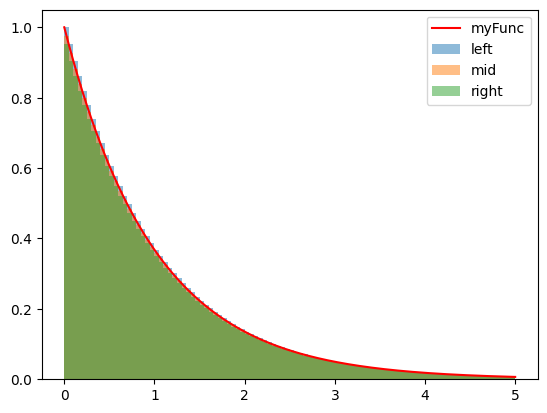

In [3]:
N = 100
xmin = 0.0
xmax = 5

# create equally spaced x values
xplot=np.linspace(xmin, xmax, np.max(N)* 10)

# get x range
x_left_test = getXRange(xmin, xmax, N, 'left')
x_mid_test = getXRange(xmin, xmax, N, 'mid')
x_right_test = getXRange(xmin, xmax, N, 'right')

# Compute step size
dx = x_left_test[1] - x_left_test[0]
print(f"dx = {dx}")

# plot rieman sum visualization
plt.figure()
plt.plot(xplot, myFunc(xplot), 'r-', label='myFunc')
plt.bar(x_left_test+dx/2, myFunc(x_left_test), dx, alpha=0.5, label='left')
plt.bar(x_mid_test, myFunc(x_mid_test), dx, alpha=0.5, label='mid')
plt.bar(x_right_test-dx/2, myFunc(x_right_test), dx, alpha=0.5, label='right')
plt.legend()
plt.show()

Obtener el área bajo la curva

In [ ]:
def riemannSum(f, xmin, xmax, N, mode):
    x = getXRange(xmin, xmax, N, mode)
    return (x[1] - x[0])*np.sum(f(x))

intlist = np.arange(1, 100, 1)
Nvals = 2**intlist

# áreas de los rectangulos
results_left = np.zeros_like(Nvals)*1.0
results_mid = np.zeros_like(Nvals)*1.0
results_right = np.zeros_like(Nvals)*1.0

for idx, n in enumerate(Nvals):
    R_left = riemannSum(myFunc, xmin, xmax, n, 'left')
    R_mid = riemannSum(myFunc, xmin, xmax, n, 'mid')
    R_right = riemannSum(myFunc, xmin, xmax, n, 'right')
    
    results_left[idx] = R_left
    results_mid[idx] = R_mid
    results_right[idx] = R_right

In [ ]:
results_left

array([2.7052125 , 1.74013443, 1.33578063, 1.15652931, 1.07288063,
       1.0325665 , 1.012788  , 1.00299345, 0.99811986])